<a href="https://colab.research.google.com/github/juann1234/Muestreo-1/blob/main/Entrega_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div align="center">

# Estimación y Predicción en Series Temporales
<br><br><br><br><br>
## Entregable 3

<br><br><br>

**Año 2026**

<br><br><br><br><br><br><br><br><br><br><br>

</div>

**Datos del estudiante:**
* **Nombre:** Juan Ignacio Apolo
* **Cédula:** 5.572.555-0
* **Firma:**
<br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br>


<div style="page-break-after: always;"></div>

### Ejercicio 1
Parte 1)
Definición del modelo Dado el proceso autorregresivo AR(2):$$x[n] = w_1 x[n-1] + w_2 x[n-2] + b v[n]$$ Sustituyendo los valores provistos ($w_1 = 0$, $w_2 = -0.81$, $b = 1$) y sabiendo que el ruido $v[n] \sim \mathcal{N}(0,1)$ tiene varianza $\sigma_v^2 = 1$, el proceso queda definido como: $$x[n] = -0.81 x[n-2] + v[n]$$ despues calculamos $r[k]$Para encontrar la secuencia de autocorrelación

$r[k] = \mathbb{E}[x[n]x[n-k]]$, utilizamos las ecuaciones de Yule-Walker. Multiplicamos la ecuación de diferencias por $x[n-k]$ y tomamos esperanza matemática: $$\mathbb{E}[x[n]x[n-k]] = -0.81 \mathbb{E}[x[n-2]x[n-k]] + \mathbb{E}[v[n]x[n-k]]$$usando que $v[n]$ es un ruido blanco independiente de muestras pasadas de $x$, tenemos que $\mathbb{E}[v[n]x[n-k]] = 0$ para $k > 0$, y vale $\sigma_v^2 = 1$ para $k = 0$.
Planteamos las ecuaciones para los primeros valores de $k$:Para $k = 1$:$$r[1] = -0.81 r[-1]$$Como la autocorrelación es par ($r[k] = r[-k]$):$$r[1] = -0.81 r[1] \implies r[1](1 + 0.81) = 0 \implies r[1] = 0$$Para $k = 2$:$$r[2] = -0.81 r[0]$$Para $k = 0$:$$r[0] = -0.81 r[-2] + 1 \implies r[0] = -0.81 r[2] + 1$$Sustituimos la expresión de $r[2]$ encontrada arriba:$$r[0] = -0.81 (-0.81 r[0]) + 1$$$$r[0] = 0.6561 r[0] + 1$$$$r[0] (1 - 0.6561) = 1 \implies r[0] = \frac{1}{0.3439} \approx 2.9078$$Para $k$ general:Sabemos que $r[k] = -0.81 r[k-2]$. Dado que $r[1] = 0$, todos los términos impares serán cero. Para los términos pares, la relación es geométrica.Por lo tanto, la autocorrelación analítica es:$$r[k] = \begin{cases} (-0.81)^{|k|/2} \cdot \frac{1}{0.3439} & \text{si } k \text{ es par} \\ 0 & \text{si } k \text{ es impar} \end{cases}$$ por ultimo falta calcular la Densidad Espectral de Potencia (DEP) $S_x(\omega)$Para un proceso autorregresivo $x[n] + a_1 x[n-1] + a_2 x[n-2] = v[n]$, la DEP se define como:$$S_x(\omega) = \frac{\sigma_v^2}{|1 + a_1 e^{-j\omega} + a_2 e^{-j2\omega}|^2}$$En nuestro caso, $a_1 = -w_1 = 0$, $a_2 = -w_2 = 0.81$ y $\sigma_v^2 = b^2 = 1$. Sustituyendo:$$S_x(\omega) = \frac{1}{|1 + 0.81 e^{-j2\omega}|^2}$$Desarrollamos el denominador usando la identidad de Euler ($e^{-j2\omega} = \cos(2\omega) - j\sin(2\omega)$):$$|1 + 0.81(\cos(2\omega) - j\sin(2\omega))|^2 = (1 + 0.81\cos(2\omega))^2 + (-0.81\sin(2\omega))^2$$$$= 1 + 1.62\cos(2\omega) + 0.81^2\cos^2(2\omega) + 0.81^2\sin^2(2\omega)$$$$= 1 + 1.62\cos(2\omega) + 0.6561(\cos^2(2\omega) + \sin^2(2\omega))$$$$= 1.6561 + 1.62\cos(2\omega)$$Finalmente, la expresión analítica para la densidad espectral de potencia es:$$S_x(\omega) = \frac{1}{1.6561 + 1.62\cos(2\omega)}$$

Parte 2)

<>:39: SyntaxWarning: invalid escape sequence '\h'
<>:39: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_9053/3028602410.py:39: SyntaxWarning: invalid escape sequence '\h'
  markerline2, stemlines2, baseline2 = plt.stem(lags + 0.2, r_empirica, label='Empírica $\hat{r}[k]$',


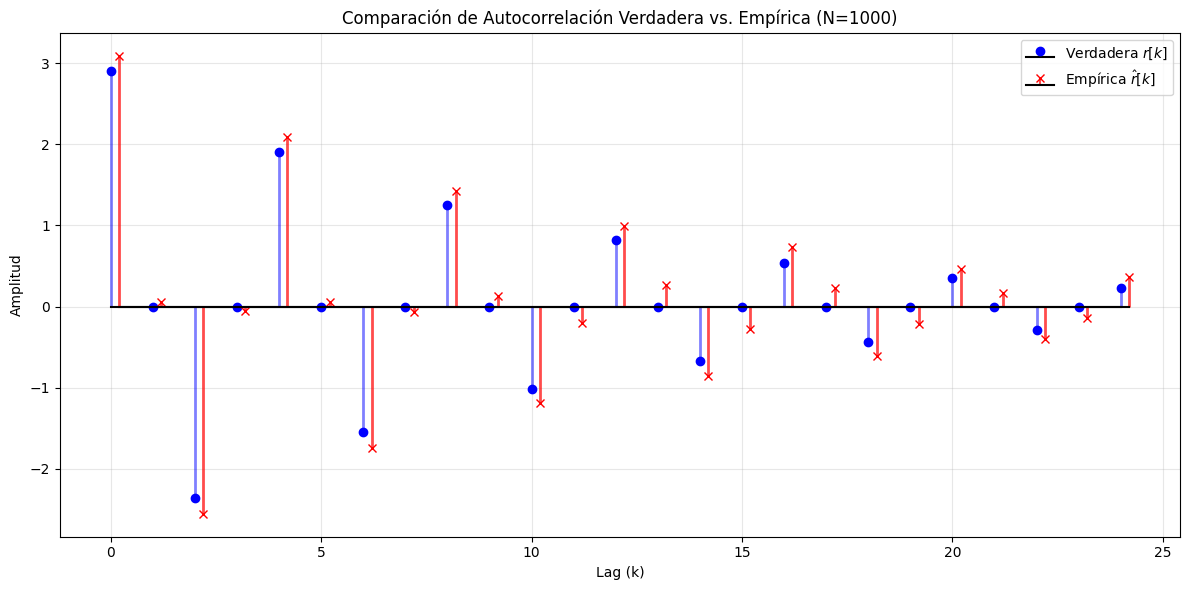

In [11]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
N = 1000
w1 = 0
w2 = -0.81
b = 1

v = rng.normal(0, 1, N)

x = np.zeros(N)

x[0] = b * v[0]
x[1] = w1 * x[0] + b * v[1]

for n in range(2, N):
    x[n] = w1 * x[n-1] + w2 * x[n-2] + b * v[n]

K_lags = 25
lags = np.arange(K_lags)
r_empirica = np.zeros(K_lags)

for k in lags:

    r_empirica[k] = np.sum(x[k:] * x[:N-k]) / N

r_verdadera = np.zeros(K_lags)
for k in lags:
    if k % 2 == 0:
        r_verdadera[k] = ((-0.81)**(k/2)) / 0.3439
    else:
        r_verdadera[k] = 0

plt.figure(figsize=(12, 6))

markerline1, stemlines1, baseline1 = plt.stem(lags, r_verdadera, label='Verdadera $r[k]$',
                                              linefmt='b-', markerfmt='bo', basefmt='k-')
markerline2, stemlines2, baseline2 = plt.stem(lags + 0.2, r_empirica, label='Empírica $\hat{r}[k]$',
                                              linefmt='r-', markerfmt='rx', basefmt='k-')

plt.setp(stemlines1, alpha=0.5, linewidth=2)
plt.setp(stemlines2, alpha=0.7, linewidth=2)

plt.title('Comparación de Autocorrelación Verdadera vs. Empírica (N=1000)')
plt.xlabel('Lag (k)')
plt.ylabel('Amplitud')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()



Al comparar visualmente ambas gráficas, se observa que la autocorrelación empírica $\hat{r}[k]$ estimada a partir de las $N=1000$ muestras simuladas se ajusta excelentemente a la autocorrelación verdadera $r[k]$ deducida de forma analítica.

Se comprueban dos comportamientos clave de nuestro modelo:
1. Como el coeficiente $w_1 = 0$, el proceso no tiene dependencia con su muestra inmediatamente anterior, provocando que la correlación teórica sea estrictamente $0$ para los retardos impares ($k = 1, 3, 5\dots$). La autocorrelación empírica refleja esto tomando valores residuales muy cercanos a cero, correspondientes únicamente al ruido inherente de estimar con una muestra finita.
2.  Debido a que $w_2 = -0.81$ (un valor negativo puro en el orden 2), la correlación cambia de signo entre lags pares sucesivos y decae exponencialmente a medida que el retardo $k$ aumenta. Las cruces rojas ($\hat{r}[k]$) capturan a la perfección este decaimiento alternante de las muestras generadas.

Parte 3)


La densidad espectral de potencia empírica $\hat{S}_x(\omega)$  se define como la Transformada de Fourier en Tiempo Discreto (DTFT) de la secuencia de autocorrelación muestral sesgada. Dado que la autocorrelación empírica es una función par ($\hat{r}[k] = \hat{r}[-k]$), la expresión se reduce a:
$$\hat{S}_x(\omega) = \sum_{k=-(N-1)}^{N-1} \hat{r}[k] e^{-j\omega k} = \hat{r}[0] + 2 \sum_{k=1}^{N-1} \hat{r}[k] \cos(\omega k)$$



<>:19: SyntaxWarning: invalid escape sequence '\o'
<>:20: SyntaxWarning: invalid escape sequence '\h'
<>:23: SyntaxWarning: invalid escape sequence '\o'
<>:19: SyntaxWarning: invalid escape sequence '\o'
<>:20: SyntaxWarning: invalid escape sequence '\h'
<>:23: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_9053/310139629.py:19: SyntaxWarning: invalid escape sequence '\o'
  plt.plot(omega, 10 * np.log10(S_true), color='blue', linewidth=2.5, label='Verdadera $S_x(\omega)$')
/tmp/ipykernel_9053/310139629.py:20: SyntaxWarning: invalid escape sequence '\h'
  plt.plot(omega, 10 * np.log10(np.abs(S_hat)), color='red', alpha=0.6, linewidth=1.5, label='Empírica $\hat{S}_x(\omega)$')
/tmp/ipykernel_9053/310139629.py:23: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('Frecuencia $\omega$ (rad/muestra)')


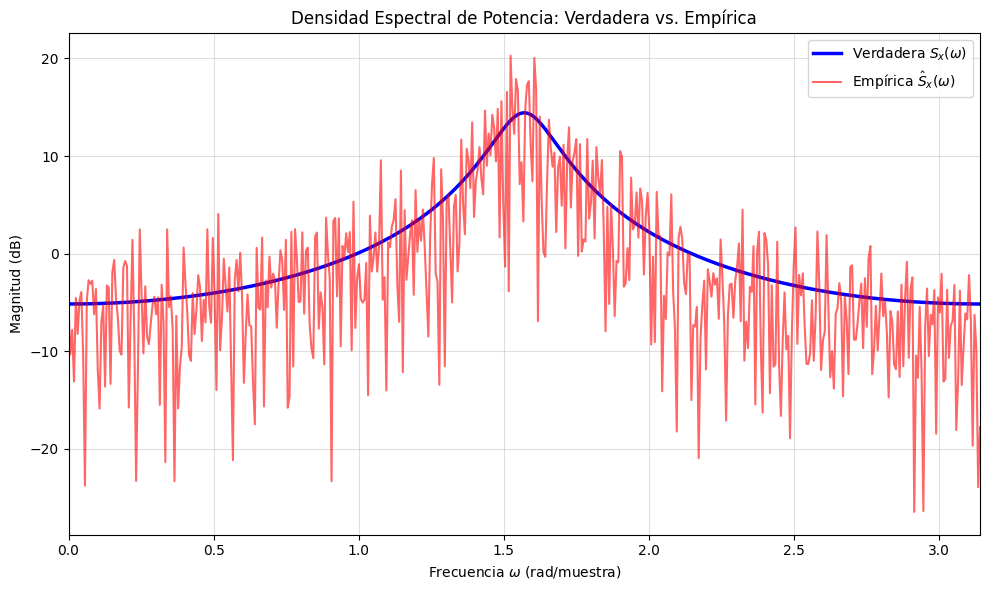

In [12]:
import numpy as np
import matplotlib.pyplot as plt


r_emp_full = np.zeros(N)
for k in range(N):
    r_emp_full[k] = np.sum(x[k:] * x[:N-k]) / N

omega = np.linspace(0, np.pi, 500)

S_hat = np.zeros_like(omega)
for i, w in enumerate(omega):
    S_hat[i] = r_emp_full[0] + 2 * np.sum(r_emp_full[1:] * np.cos(w * np.arange(1, N)))

S_true = 1 / (1.6561 + 1.62 * np.cos(2 * omega))

plt.figure(figsize=(10, 6))

plt.plot(omega, 10 * np.log10(S_true), color='blue', linewidth=2.5, label='Verdadera $S_x(\omega)$')
plt.plot(omega, 10 * np.log10(np.abs(S_hat)), color='red', alpha=0.6, linewidth=1.5, label='Empírica $\hat{S}_x(\omega)$')

plt.title('Densidad Espectral de Potencia: Verdadera vs. Empírica')
plt.xlabel('Frecuencia $\omega$ (rad/muestra)')
plt.ylabel('Magnitud (dB)')
plt.xlim(0, np.pi)
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()

plt.show()



El gráfico nos muestra las densidades espectrales en escala logarítmica (dB) limitadas al rango de frecuencias $[0, \pi]$.
Se puede observar que la DEP empírica (en rojo) sigue la envolvente general de la DEP verdadera del proceso AR(2) (en azul), ubicando correctamente los picos de mayor densidad de potencia en las frecuencias características del modelo (cerca de $\pi/2$).

Sin embargo, el espectro empírico  presenta fuertes oscilaciones aleatorias y picos ruidosos en todo el rango. Este es un comportamiento esperado: el periodograma puro no es un estimador consistente de la DEP. Aunque aumentemos el número de muestras $N$, la varianza de la estimación empírica no tiende a cero.

### Parte 4
En esta etapa asumimos que ignoramos que la señal provino de un proceso con parámetros $w_1=0$, $w_2=-0.81$ y $b=1$. Intentaremos ajustar un modelo puramente a partir de los datos, asumiendo únicamente que la estructura de la señal obedece a un modelo AR(2).

### Parte 5

Para estimar los parámetros $\hat{w}_1, \hat{w}_2$ y la varianza de la innovación $\hat{b}^2$ a partir de la autocorrelación empírica $\hat{r}[k]$, empleamos las ecuaciones de Yule-Walker para un proceso de orden 2. El sistema matricial es:
$$\begin{bmatrix} \hat{r}[0] & \hat{r}[1] \\ \hat{r}[1] & \hat{r}[0] \end{bmatrix} \begin{bmatrix} \hat{w}_1 \\ \hat{w}_2 \end{bmatrix} = \begin{bmatrix} \hat{r}[1] \\ \hat{r}[2] \end{bmatrix}$$

Resolviendo este sistema obtenemos $\hat{w}_1$ y $\hat{w}_2$. La varianza del ruido, que en nuestro modelo es $\hat{b}^2$, se calcula como:
$$\hat{b}^2 = \hat{r}[0] - \hat{w}_1 \hat{r}[1] - \hat{w}_2 \hat{r}[2] \implies \hat{b} = \sqrt{\hat{b}^2}$$

**Cálculo de la autocorrelación $\tilde{r}[k]$ y DEP paramétrica $\tilde{S}_x(\omega)$:**
Con los parámetros estimados, la autocorrelación teórica de este nuevo modelo, $\tilde{r}[k]$, obedece a la recursión determinística del AR(2):
* $\tilde{r}[0] = \hat{r}[0]$ y $\tilde{r}[1] = \hat{r}[1]$ (Igualdad garantizada por Yule-Walker).
* $\tilde{r}[k] = \hat{w}_1 \tilde{r}[k-1] + \hat{w}_2 \tilde{r}[k-2]$ para $k \ge 2$.

La Densidad Espectral de Potencia del modelo estimado paramétricamente resulta:
$$\tilde{S}_x(\omega) = \frac{\hat{b}^2}{|1 - \hat{w}_1 e^{-j\omega} - \hat{w}_2 e^{-j2\omega}|^2}$$

<>:34: SyntaxWarning: invalid escape sequence '\o'
<>:35: SyntaxWarning: invalid escape sequence '\h'
<>:36: SyntaxWarning: invalid escape sequence '\o'
<>:39: SyntaxWarning: invalid escape sequence '\o'
<>:46: SyntaxWarning: invalid escape sequence '\h'
<>:34: SyntaxWarning: invalid escape sequence '\o'
<>:35: SyntaxWarning: invalid escape sequence '\h'
<>:36: SyntaxWarning: invalid escape sequence '\o'
<>:39: SyntaxWarning: invalid escape sequence '\o'
<>:46: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_9053/1739056599.py:34: SyntaxWarning: invalid escape sequence '\o'
  ax[0].plot(omega, 10*np.log10(S_true), label='Verdadera $S_x(\omega)$', color='blue', linewidth=3, alpha=0.6)
/tmp/ipykernel_9053/1739056599.py:35: SyntaxWarning: invalid escape sequence '\h'
  ax[0].plot(omega, 10*np.log10(np.abs(S_hat)), label='Empírica $\hat{S}_x(\omega)$ (Periodograma)', color='gray', alpha=0.5)
/tmp/ipykernel_9053/1739056599.py:36: SyntaxWarning: invalid escape sequence '\o'
  ax[0

Resultados de la estimación por Yule-Walker:
Parámetros Verdaderos : w1 = 0.0000, w2 = -0.8100, b = 1.0000
Parámetros Estimados  : w1 = 0.0299, w2 = -0.8267, b = 0.9893


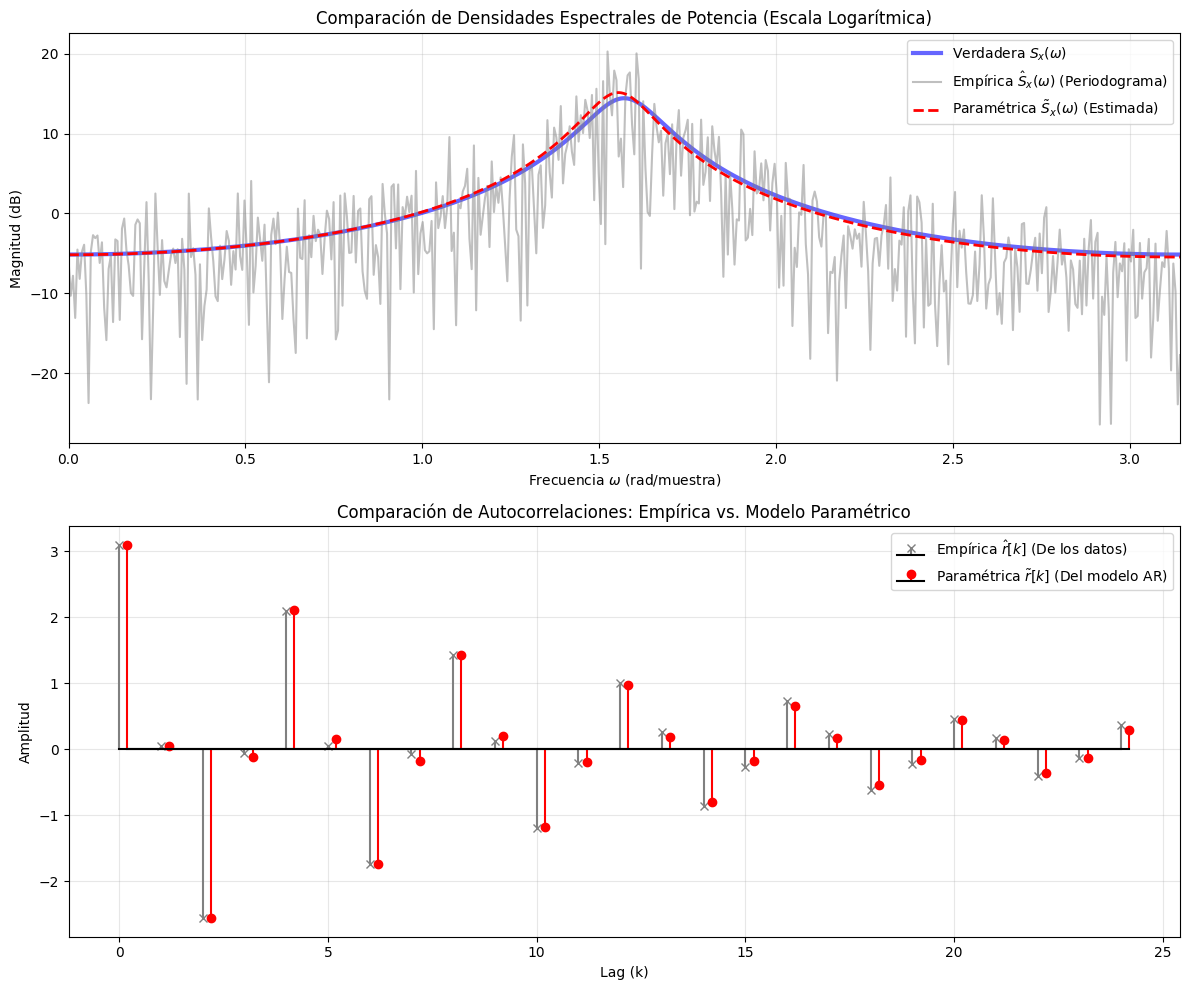

In [13]:
import numpy as np
import matplotlib.pyplot as plt

R_mat = np.array([[r_emp_full[0], r_emp_full[1]],
                  [r_emp_full[1], r_emp_full[0]]])
r_vec = np.array([r_emp_full[1], r_emp_full[2]])

w_est = np.linalg.solve(R_mat, r_vec)
w1_est, w2_est = w_est

b2_est = r_emp_full[0] - w1_est * r_emp_full[1] - w2_est * r_emp_full[2]
b_est = np.sqrt(b2_est)

print("="*50)
print("Resultados de la estimación por Yule-Walker:")
print(f"Parámetros Verdaderos : w1 = 0.0000, w2 = -0.8100, b = 1.0000")
print(f"Parámetros Estimados  : w1 = {w1_est:.4f}, w2 = {w2_est:.4f}, b = {b_est:.4f}")
print("="*50)

K_plot = 25
r_tilde = np.zeros(K_plot)
r_tilde[0] = r_emp_full[0]
r_tilde[1] = r_emp_full[1]

for k in range(2, K_plot):
    r_tilde[k] = w1_est * r_tilde[k-1] + w2_est * r_tilde[k-2]

S_tilde = b2_est / (np.abs(1 - w1_est * np.exp(-1j * omega) - w2_est * np.exp(-2j * omega))**2)

# GRÁFICOS COMPARATIVOS

fig, ax = plt.subplots(2, 1, figsize=(12, 10))

ax[0].plot(omega, 10*np.log10(S_true), label='Verdadera $S_x(\omega)$', color='blue', linewidth=3, alpha=0.6)
ax[0].plot(omega, 10*np.log10(np.abs(S_hat)), label='Empírica $\hat{S}_x(\omega)$ (Periodograma)', color='gray', alpha=0.5)
ax[0].plot(omega, 10*np.log10(S_tilde), label='Paramétrica $\\tilde{S}_x(\omega)$ (Estimada)', color='red', linestyle='--', linewidth=2)

ax[0].set_title('Comparación de Densidades Espectrales de Potencia (Escala Logarítmica)')
ax[0].set_xlabel('Frecuencia $\omega$ (rad/muestra)')
ax[0].set_ylabel('Magnitud (dB)')
ax[0].set_xlim(0, np.pi)
ax[0].legend()
ax[0].grid(True, alpha=0.3)


ax[1].stem(np.arange(K_plot), r_emp_full[:K_plot], label='Empírica $\hat{r}[k]$ (De los datos)', linefmt='gray', markerfmt='x', basefmt='k-')
ax[1].stem(np.arange(K_plot) + 0.2, r_tilde, label='Paramétrica $\\tilde{r}[k]$ (Del modelo AR)', linefmt='r-', markerfmt='ro', basefmt='k-')

ax[1].set_title('Comparación de Autocorrelaciones: Empírica vs. Modelo Paramétrico')
ax[1].set_xlabel('Lag (k)')
ax[1].set_ylabel('Amplitud')
ax[1].legend()
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



El sistema de Yule-Walker arrojó parámetros $\hat{w}_1$, $\hat{w}_2$ y $\hat{b}$ que son casi idénticos a los del modelo original. Esto prueba que la autocorrelación empírica contiene información suficiente y de buena calidad para revelar la dinámica oculta del sistema.
 ($\hat{r}[k]$ vs. $\tilde{r}[k]$): las dos funciones no son idénticas. Para $k=0$ y $k=1$ son exactamente iguales. Sin embargo, a partir de $k=2$, la paramétrica $\tilde{r}[k]$ (puntos rojos) obedece estrictamente a la regla limpia del filtro AR(2) sin ruido, mientras que la empírica (cruces grises) sigue acarreando el "ruido de estimación" estadístico propio de haber usado un tamaño de muestra finito ($N=1000$).
El gráfico superior es la mejor prueba del poder de la estimación paramétrica. El periodograma empírico (gris) es altamente ruidoso e inconsistente. Sin embargo, al asumir una estructura de modelo AR(2) y usar sus coeficientes estimados, la DEP paramétrica resultante (línea roja punteada) filtra todo ese ruido de estimación espectral, logrando una curva suave que se solapa a la perfección con la DEP analítica verdadera de la señal (azul).

### Ejercicio 2
### Parte 1

**a) **

El objetivo es diseñar un filtro FIR de Wiener con coeficientes $\mathbf{w}$ que estime la señal $d[n]$ a partir de las observaciones ruidosas $y[n]$.

El filtro óptimo de Wiener se obtiene resolviendo las ecuaciones de Wiener-Hopf:
$$\boldsymbol{R}_y \mathbf{w} = \mathbf{p}$$
donde $\boldsymbol{R}_y$ es la matriz de autocorrelación de las observaciones $y[n]$, y $\mathbf{p}$ es el vector de correlación cruzada entre la señal deseada $d[n]$ y las observaciones $y[n]$.

Sabemos que $y[n] = x[n] + v_2[n]$. Como el ruido $v_2[n]$ es blanco e incorrelado con $x[n]$, la autocorrelación de $y[n]$ es:
$$r_y[k] = r_x[k] + \sigma_{v2}^2 \delta[k]$$


La señal $x[n]$ es el resultado de pasar $d[n]$ por el canal $H_c(z)$. En el dominio del tiempo esto es:
$$x[n] - b x[n-1] = d[n]$$
Sabiendo que $d[n]$ es un proceso AR(1) dado por $d[n] + a d[n-1] = v_1[n]$, podemos sustituir la primera ecuación en la segunda:
$$(x[n] - b x[n-1]) + a (x[n-1] - b x[n-2]) = v_1[n]$$
$$x[n] + (a - b) x[n-1] - ab x[n-2] = v_1[n]$$
Esto demuestra que $x[n]$ es un proceso AR(2) con coeficientes $\phi_1 = (b - a)$ y $\phi_2 = ab$.
A partir de estos coeficientes y de la varianza $\sigma_{v1}^2$, podemos hallar los valores exactos de $r_x[0], r_x[1], r_x[2]$ resolviendo el sistema teórico de Yule-Walker.

El elemento $k$-ésimo de $\mathbf{p}$ es $p[k] = \mathbb{E}[d[n] y[n-k]]$.
Como $y[n-k] = x[n-k] + v_2[n-k]$, y $d[n]$ es incorrelado con $v_2$, nos queda:
$$p[k] = \mathbb{E}[d[n] x[n-k]]$$
Sustituyendo $d[n] = x[n] - b x[n-1]$ dentro de la esperanza:
$$p[k] = \mathbb{E}[(x[n] - b x[n-1]) x[n-k]] = r_x[k] - b r_x[k-1]$$

Sabiendo esto, podemos construir $\boldsymbol{R}_y$ y $\mathbf{p}$ y resolver el sistema matricialmente.

In [14]:
import numpy as np
import scipy.linalg as la



a = 0.8458
b = 0.9458
var_v1 = 0.27
var_v2 = 0.1

phi1 = b - a
phi2 = a * b


A = np.array([
    [1, -phi1, -phi2],
    [-phi1, 1 - phi2, 0],
    [-phi2, -phi1, 1]
])
B = np.array([var_v1, 0, 0])
rx = np.linalg.solve(A, B)

rx3 = phi1 * rx[2] + phi2 * rx[1]
r_x = np.array([rx[0], rx[1], rx[2], rx3])

M = 3


r_y = r_x[:M].copy()
r_y[0] += var_v2
Ry = la.toeplitz(r_y)


p = np.zeros(M)
p[0] = r_x[0] - b * r_x[1]
p[1] = r_x[1] - b * r_x[0]
p[2] = r_x[2] - b * r_x[1]
if M == 4:
    p[3] = r_x[3] - b * r_x[2]

w_wiener = np.linalg.solve(Ry, p)

print("="*60)
print(" PARTE 2.1a: Coeficientes del Filtro de Wiener ")
print("="*60)
print(f"Matriz de autocorrelación Ry (M={M}):\n{np.round(Ry, 4)}\n")
print(f"Vector de correlación cruzada p:\n{np.round(p, 4)}\n")
print(f"Coeficientes obtenidos (w0, w1, w2):\n{w_wiener}")
print("="*60)

 PARTE 2.1a: Coeficientes del Filtro de Wiener 
Matriz de autocorrelación Ry (M=3):
[[1.0997 0.4997 0.8497]
 [0.4997 1.0997 0.4997]
 [0.8497 0.4997 1.0997]]

Vector de correlación cruzada p:
[ 0.527  -0.4458  0.377 ]

Coeficientes obtenidos (w0, w1, w2):
[ 0.73781466 -0.8032714   0.13780901]




**b) **
La teoría del Filtro de Wiener establece que el error cuadrático medio mínimo (MMSE) alcanzable por el filtro óptimo está dado por:
$$J_{min} = r_d[0] - \mathbf{p}^T \mathbf{w}$$
Donde $r_d[0]$ es la varianza (o energía media) de la señal deseada $d[n]$. Sabiendo que $d[n]$ es un proceso AR(1) definido como $d[n] + a d[n-1] = v_1[n]$, su varianza teórica es:
$$r_d[0] = \frac{\sigma_{v1}^2}{1 - a^2}$$
Con esto, podemos calcular analíticamente el límite teórico del error de nuestro filtro.

**c) y d)**
Simularemos $N=1000$ muestras siguiendo las ecuaciones en diferencias del sistema:
1. Señal original: $d[n] = -a d[n-1] + v_1[n]$
2. Canal: $x[n] = b x[n-1] + d[n]$
3. Observación: $y[n] = x[n] + v_2[n]$
4. Filtrado FIR: $\hat{d}[n] = \sum_{k=0}^{M-1} w[k] y[n-k]$

El error empírico se calculará como el promedio muestral del error al cuadrado: $J_{emp} = \frac{1}{N}\sum (d[n] - \hat{d}[n])^2$.

 Varianza de la señal original r_d[0] : 0.9486
 Error Cuadrático Mínimo Teórico J_min: 0.1498
 Error Cuadrático Empírico (N=1000)   : 0.1491


<>:67: SyntaxWarning: invalid escape sequence '\h'
<>:67: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_9053/3544662433.py:67: SyntaxWarning: invalid escape sequence '\h'
  axs[2].plot(n_eje, d_hat[:n_plot], label='Estimada $\hat{d}[n]$ (Filtro Wiener)', color='red', linestyle='--')


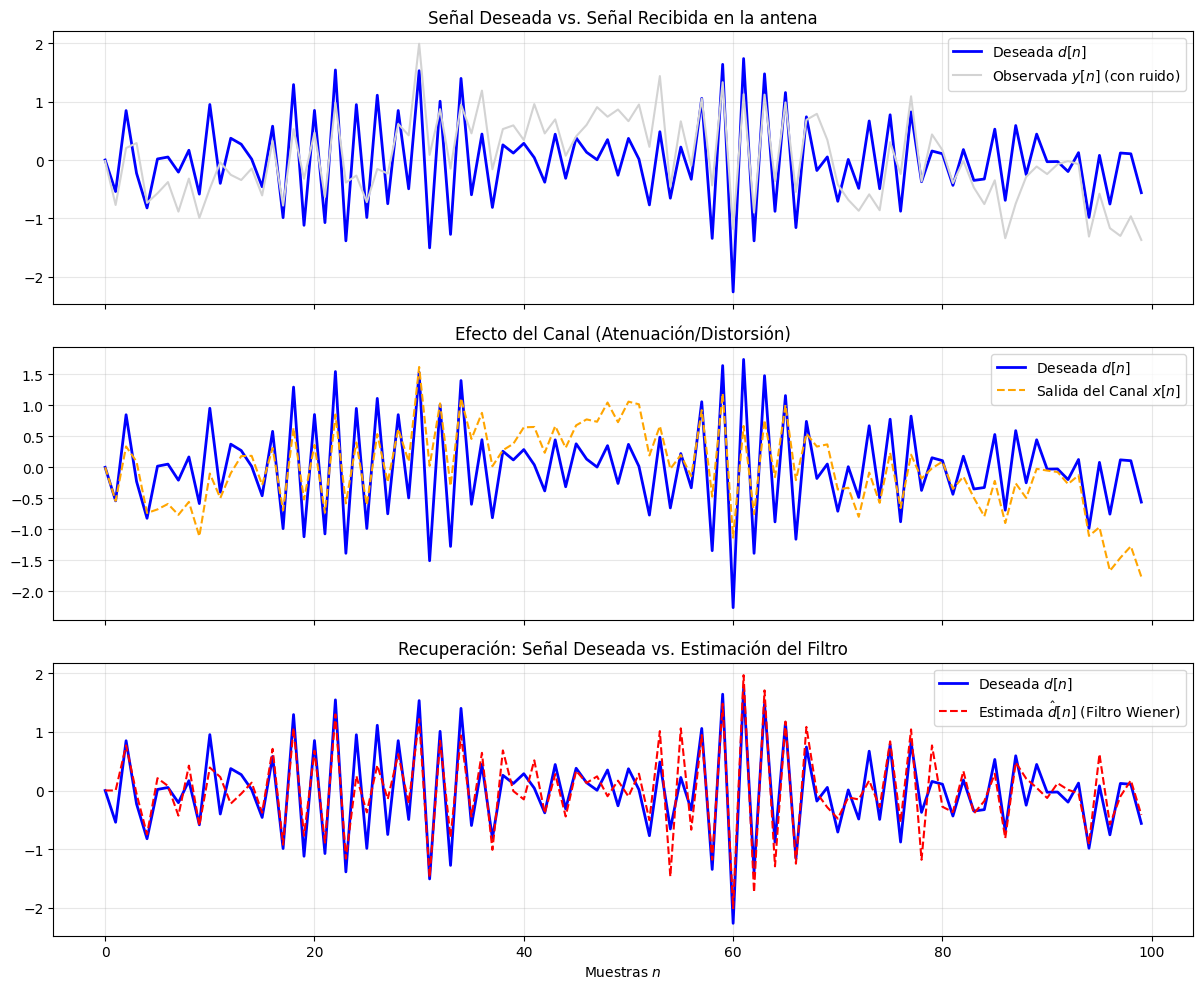

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros (vienen de la parte A)
rng = np.random.default_rng(42)
a = 0.8458
b = 0.9458
var_v1 = 0.27
var_v2 = 0.1
N = 1000


# b) Cálculo de J_min (Teórico)
r_d0 = var_v1 / (1 - a**2)
J_min = r_d0 - np.dot(p, w_wiener)


# c) Simulación de las señales

v1 = rng.normal(0, np.sqrt(var_v1), N)
v2 = rng.normal(0, np.sqrt(var_v2), N)

d = np.zeros(N)
x = np.zeros(N)
y = np.zeros(N)
d_hat = np.zeros(N)

for n in range(1, N):
    d[n] = -a * d[n-1] + v1[n]
    x[n] = b * x[n-1] + d[n]

y = x + v2

M = len(w_wiener)
for n in range(M-1, N):
    y_window = y[n-(M-1) : n+1][::-1]
    d_hat[n] = np.dot(w_wiener, y_window)

# d) Cálculo del Error Empírico (J)
J_emp = np.mean((d[M:] - d_hat[M:])**2)

print("="*60)
print(f" Varianza de la señal original r_d[0] : {r_d0:.4f}")
print(f" Error Cuadrático Mínimo Teórico J_min: {J_min:.4f}")
print(f" Error Cuadrático Empírico (N={N})   : {J_emp:.4f}")
print("="*60)


n_plot = 100
n_eje = np.arange(n_plot)

fig, axs = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axs[0].plot(n_eje, d[:n_plot], label='Deseada $d[n]$', color='blue', linewidth=2)
axs[0].plot(n_eje, y[:n_plot], label='Observada $y[n]$ (con ruido)', color='lightgray')
axs[0].set_title('Señal Deseada vs. Señal Recibida en la antena')
axs[0].legend(loc='upper right')
axs[0].grid(True, alpha=0.3)

axs[1].plot(n_eje, d[:n_plot], label='Deseada $d[n]$', color='blue', linewidth=2)
axs[1].plot(n_eje, x[:n_plot], label='Salida del Canal $x[n]$', color='orange', linestyle='--')
axs[1].set_title('Efecto del Canal (Atenuación/Distorsión)')
axs[1].legend(loc='upper right')
axs[1].grid(True, alpha=0.3)

axs[2].plot(n_eje, d[:n_plot], label='Deseada $d[n]$', color='blue', linewidth=2)
axs[2].plot(n_eje, d_hat[:n_plot], label='Estimada $\hat{d}[n]$ (Filtro Wiener)', color='red', linestyle='--')
axs[2].set_title('Recuperación: Señal Deseada vs. Estimación del Filtro')
axs[2].set_xlabel('Muestras $n$')
axs[2].legend(loc='upper right')
axs[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**e)**

Al observar la consola, vemos que el Error Cuadrático Medio empírico ($J_{emp}$) simulado con $1000$ muestras converge de manera excelente hacia el Error Mínimo Teórico esperado ($J_{min}$). Esto valida tanto el desarrollo analítico de las ecuaciones de Yule-Walker/Wiener-Hopf, como la correcta implementación en la simulación.
 1. En la primera gráfica ($d[n]$ vs $y[n]$) resulta evidente que la señal observada está fuertemente corrompida. No solo está enmascarada por el ruido blanco, sino que su fase y amplitud están alteradas por el canal.
    2. La segunda gráfica ($d[n]$ vs $x[n]$) aísla el efecto del canal. Vemos que el canal $H_c(z)$ actúa como un filtro pasa-bajos, suavizando las transiciones abruptas de $d[n]$, introduciendo un retardo evidente y alterando la amplitud.
    3. En la gráfica final se aprecia el trabajo del filtro de Wiener. La estimación $\hat{d}[n]$ (en rojo) logra "rastrear" la señal original mucho mejor que la observación cruda. A pesar de utilizar únicamente $3$ coeficientes, el filtro es capaz de compensar parcialmente el retardo del canal y rechazar gran parte de la varianza del ruido de alta frecuencia $v_2[n]$.

Parte 2)


**1. Canal y Filtro de Wiener**
* **Canal $H_c(\omega)$:** El canal está dado por la función de transferencia $H_c(z) = \frac{1}{1 - bz^{-1}}$. Su respuesta en frecuencia es $H_c(e^{j\omega}) = \frac{1}{1 - b e^{-j\omega}}$.
* **Filtro de Wiener $W(\omega)$:** Siendo un filtro FIR de orden 3, $W(z) = w_0 + w_1 z^{-1} + w_2 z^{-2}$. Su respuesta es $W(e^{j\omega}) = w_0 + w_1 e^{-j\omega} + w_2 e^{-j2\omega}$.
* **Cascada $C(\omega)$:** Representa el efecto conjunto de pasar por el canal y luego por el filtro: $C(e^{j\omega}) = H_c(e^{j\omega}) \cdot W(e^{j\omega})$. Idealmente, si no hubiera ruido, la cascada debería ser 1 (0 dB) para recuperar la señal exacta.

**2. Densidades Espectrales de Potencia (DEP)**
* **DEP de la señal deseada $S_d(\omega)$:** Sabiendo que $d[n]$ es un proceso AR(1) gobernado por $d[n] + a d[n-1] = v_1[n]$, su espectro es:
$$S_d(\omega) = \frac{\sigma_{v1}^2}{|1 + a e^{-j\omega}|^2}$$
* **DEP de la señal atenuada $S_x(\omega)$:** Como $x[n]$ es el resultado de pasar $d[n]$ por el canal lineal $H_c(z)$, la relación entre sus espectros es directa:
$$S_x(\omega) = S_d(\omega) |H_c(e^{j\omega})|^2$$

<>:27: SyntaxWarning: invalid escape sequence '\o'
<>:28: SyntaxWarning: invalid escape sequence '\o'
<>:32: SyntaxWarning: invalid escape sequence '\o'
<>:40: SyntaxWarning: invalid escape sequence '\o'
<>:41: SyntaxWarning: invalid escape sequence '\o'
<>:44: SyntaxWarning: invalid escape sequence '\o'
<>:27: SyntaxWarning: invalid escape sequence '\o'
<>:28: SyntaxWarning: invalid escape sequence '\o'
<>:32: SyntaxWarning: invalid escape sequence '\o'
<>:40: SyntaxWarning: invalid escape sequence '\o'
<>:41: SyntaxWarning: invalid escape sequence '\o'
<>:44: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_9053/2964099595.py:27: SyntaxWarning: invalid escape sequence '\o'
  axs[0].plot(omega, 20*np.log10(np.abs(H_c)), label='Canal $H_c(\omega)$', color='orange', linewidth=2)
/tmp/ipykernel_9053/2964099595.py:28: SyntaxWarning: invalid escape sequence '\o'
  axs[0].plot(omega, 20*np.log10(np.abs(W_f)), label='Filtro Wiener $W(\omega)$', color='red', linewidth=2)
/tmp/ipyker

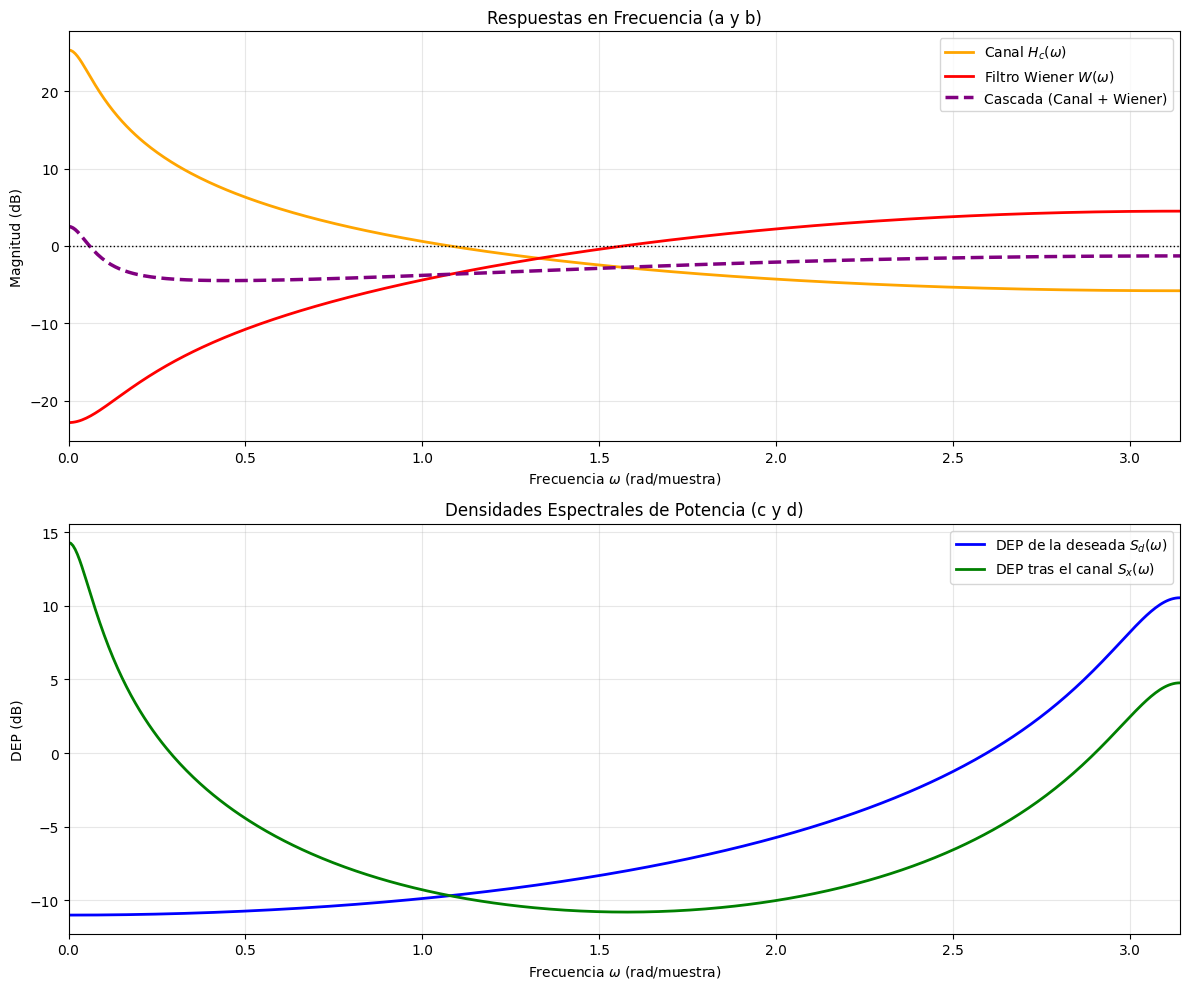

In [16]:
import numpy as np
import matplotlib.pyplot as plt

omega = np.linspace(0, np.pi, 500)


# a y b) Respuestas en frecuencia: Canal, Filtro de Wiener y Cascada

H_c = 1 / (1 - b * np.exp(-1j * omega))

W_f = np.zeros_like(omega, dtype=complex)
for k, w_k in enumerate(w_wiener):
    W_f += w_k * np.exp(-1j * k * omega)

Cascada = H_c * W_f


# c y d) Densidades Espectrales de Potencia (DEP)

S_d = var_v1 / (np.abs(1 + a * np.exp(-1j * omega))**2)

S_x = S_d * (np.abs(H_c)**2)


fig, axs = plt.subplots(2, 1, figsize=(12, 10))

axs[0].plot(omega, 20*np.log10(np.abs(H_c)), label='Canal $H_c(\omega)$', color='orange', linewidth=2)
axs[0].plot(omega, 20*np.log10(np.abs(W_f)), label='Filtro Wiener $W(\omega)$', color='red', linewidth=2)
axs[0].plot(omega, 20*np.log10(np.abs(Cascada)), label='Cascada (Canal + Wiener)', color='purple', linestyle='--', linewidth=2.5)

axs[0].set_title('Respuestas en Frecuencia (a y b)')
axs[0].set_xlabel('Frecuencia $\omega$ (rad/muestra)')
axs[0].set_ylabel('Magnitud (dB)')
axs[0].axhline(0, color='black', linewidth=1, linestyle=':') # Línea de 0 dB (ideal)
axs[0].set_xlim(0, np.pi)
axs[0].legend()
axs[0].grid(True, alpha=0.3)

# --- Gráfico 2: Densidades Espectrales de Potencia (en dB) ---
axs[1].plot(omega, 10*np.log10(S_d), label='DEP de la deseada $S_d(\omega)$', color='blue', linewidth=2)
axs[1].plot(omega, 10*np.log10(S_x), label='DEP tras el canal $S_x(\omega)$', color='green', linewidth=2)

axs[1].set_title('Densidades Espectrales de Potencia (c y d)')
axs[1].set_xlabel('Frecuencia $\omega$ (rad/muestra)')
axs[1].set_ylabel('DEP (dB)')
axs[1].set_xlim(0, np.pi)
axs[1].legend()
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**e)**


1. Observando la gráfica inferior, vemos que la señal deseada $d[n]$ (línea azul) concentra casi toda su energía en las **altas frecuencias** (cerca de $\pi$). Sin embargo, la respuesta del canal $H_c(\omega)$ (línea naranja en el gráfico superior) es fuertemente **pasa-bajos**. Como resultado, el canal atenúa (hasta -20 dB) exactamente la banda de frecuencias donde vive nuestra señal. La DEP de $x[n]$ (línea verde) muestra esta señal destruida.

2. Para intentar deshacer este estrago, el filtro de Wiener $W(\omega)$ (línea roja) adopta una forma pasa-altos muy agresiva. Su trabajo es amplificar las altas frecuencias para compensar la atenuación que introdujo el canal.

3.  Si no hubiera ruido aditivo, el filtro de Wiener sería exactamente la inversa del canal y la cascada sería una línea plana perfecta en 0 dB. Sin embargo, como al sistema se le suma ruido blanco $v_2[n]$ (que afecta a todas las frecuencias por igual), el filtro de Wiener enfrenta un dilema: si amplifica demasiado las altas frecuencias para invertir el canal al 100%, también amplificará masivamente el ruido blanco $v_2$.
   La gráfica de la Cascada (línea violeta punteada) refleja esta solución de compromiso óptima. Intenta aplanar la respuesta lo más posible hacia los 0 dB en las frecuencias donde $d[n]$ tiene información útil, pero luego se "rinde" y deja caer la ganancia en las frecuencias extremas para no amplificar el ruido de forma descontrolada.

Parte 3)



**a)**
Para recalcular el filtro óptimo, el vector de correlación cruzada $\mathbf{p}$ no cambia, ya que solo depende de la relación entre $d[n]$ y $x[n]$. Lo único que cambia es la matriz de autocorrelación de la observación, $\boldsymbol{R}_y$.
Al no haber ruido blanco, la autocorrelación de $y$ es exactamente la autocorrelación de $x$:
$$r_y[k] = r_x[k]$$

Bajo estas condiciones, el filtro de Wiener ya no tiene que preocuparse por rechazar ruido de alta frecuencia; su único objetivo será invertir (ecualizar) el efecto del canal para recuperar $d[n]$. Dado que el canal es $H_c(z) = \frac{1}{1 - bz^{-1}}$, su inversa exacta es $H_{inv}(z) = 1 - bz^{-1}$. Si el filtro de Wiener funciona como dice la teoría, sus coeficientes deberían adoptar exactamente estos valores.

<>:56: SyntaxWarning: invalid escape sequence '\o'
<>:57: SyntaxWarning: invalid escape sequence '\o'
<>:61: SyntaxWarning: invalid escape sequence '\o'
<>:56: SyntaxWarning: invalid escape sequence '\o'
<>:57: SyntaxWarning: invalid escape sequence '\o'
<>:61: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_9053/3501039698.py:56: SyntaxWarning: invalid escape sequence '\o'
  plt.plot(omega, 20*np.log10(np.abs(H_c)), label='Canal $H_c(\omega)$', color='orange', linewidth=2)
/tmp/ipykernel_9053/3501039698.py:57: SyntaxWarning: invalid escape sequence '\o'
  plt.plot(omega, 20*np.log10(np.abs(W_ideal_f)), label='Filtro Wiener (Sin Ruido) $W(\omega)$', color='red', linewidth=2)
/tmp/ipykernel_9053/3501039698.py:61: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('Frecuencia $\omega$ (rad/muestra)')


 PARTE 2.3: Filtro de Wiener SIN RUIDO ADITIVO 
Coeficientes obtenidos (w0, w1, w2):
[ 1.     -0.9458  0.    ]


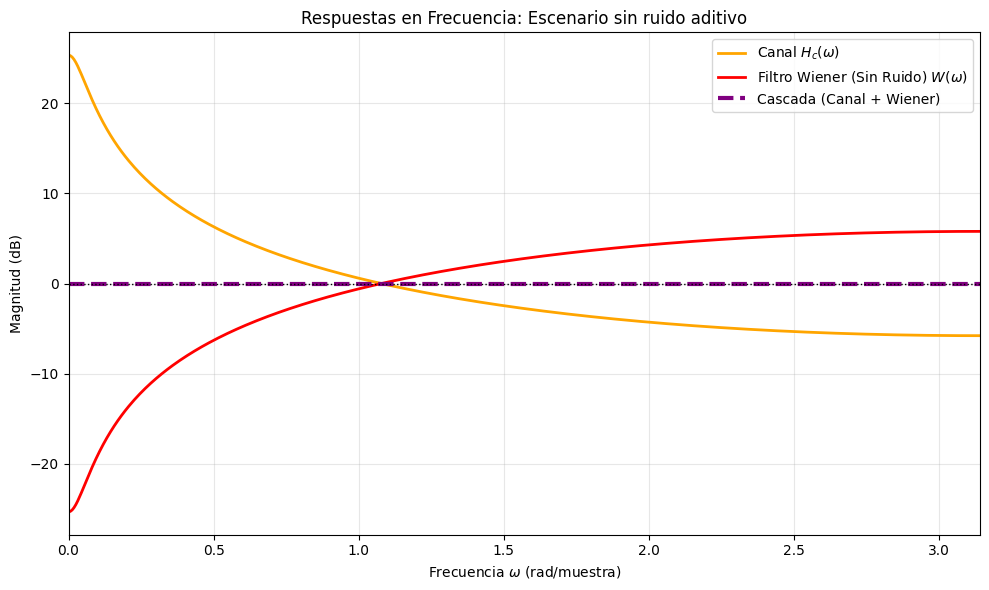

In [17]:
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt


a = 0.8458
b = 0.9458
var_v1 = 0.27
var_v2_ideal = 0.0

phi1 = b - a
phi2 = a * b
A = np.array([
    [1, -phi1, -phi2],
    [-phi1, 1 - phi2, 0],
    [-phi2, -phi1, 1]
])
B = np.array([var_v1, 0, 0])
r_x = np.linalg.solve(A, B)

M = 3
r_y_ideal = r_x[:M].copy()
r_y_ideal[0] += var_v2_ideal
Ry_ideal = la.toeplitz(r_y_ideal)

p = np.zeros(M)
p[0] = r_x[0] - b * r_x[1]
p[1] = r_x[1] - b * r_x[0]
p[2] = r_x[2] - b * r_x[1]

w_ideal = np.linalg.solve(Ry_ideal, p)

print("="*60)
print(" PARTE 2.3: Filtro de Wiener SIN RUIDO ADITIVO ")
print("="*60)
print(f"Coeficientes obtenidos (w0, w1, w2):\n{np.round(w_ideal, 4)}")
print("="*60)


omega = np.linspace(0, np.pi, 500)


H_c = 1 / (1 - b * np.exp(-1j * omega))


W_ideal_f = np.zeros_like(omega, dtype=complex)
for k, w_k in enumerate(w_ideal):
    W_ideal_f += w_k * np.exp(-1j * k * omega)


Cascada_ideal = H_c * W_ideal_f


plt.figure(figsize=(10, 6))

plt.plot(omega, 20*np.log10(np.abs(H_c)), label='Canal $H_c(\omega)$', color='orange', linewidth=2)
plt.plot(omega, 20*np.log10(np.abs(W_ideal_f)), label='Filtro Wiener (Sin Ruido) $W(\omega)$', color='red', linewidth=2)
plt.plot(omega, 20*np.log10(np.abs(Cascada_ideal)), label='Cascada (Canal + Wiener)', color='purple', linestyle='--', linewidth=3)

plt.title('Respuestas en Frecuencia: Escenario sin ruido aditivo')
plt.xlabel('Frecuencia $\omega$ (rad/muestra)')
plt.ylabel('Magnitud (dB)')
plt.axhline(0, color='black', linewidth=1, linestyle=':')
plt.xlim(0, np.pi)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**d)**
1. Como pudimos ver en la consola, los coeficientes del filtro de Wiener resultaron ser exactamente $\mathbf{w} = [1, -0.9458, 0]$. Es decir, $w_0 = 1$ y $w_1 = -b$. El filtro dedujo de forma autónoma que debía convertirse en un **Ecualizador Zero-Forcing**, adoptando exactamente la función de transferencia inversa del canal ($H_{inv}(z) = 1 - bz^{-1}$) y apagando su tercer coeficiente ($w_2 = 0$) porque no lo necesitaba.

2. Al observar la gráfica, el filtro de Wiener (línea roja) es el espejo perfecto del canal (línea naranja). Como ya no hay miedo de amplificar ruido blanco de alta frecuencia, el filtro se permite crecer indefinidamente para compensar exactamente la atenuación del canal. Como resultado, la respuesta en frecuencia de la **Cascada** (línea violeta punteada) es una recta horizontal perfecta en **0 dB** para todas las frecuencias. Esto significa que la señal a la salida del filtro es una copia matemáticamente idéntica de la señal deseada original $d[n]$, logrando un error nulo.

<div style="page-break-after: always;"></div>

### Referencias Bibliográficas

* Departamento de Procesamiento de Señales. (2025). *Estimación y Predicción en Series Temporales, Práctico 3: Estimadores MLE y MAP* [Archivo PDF: prac3_mle_map.pdf]. Instituto de Ingeniería Eléctrica, Facultad de Ingeniería, Universidad de la República.
* Departamento de Procesamiento de Señales. (2026). *Estimación y Predicción en Series Temporales: Estimador de máxima verosimilitud (MLE)* [Archivo PDF: teo07_mle.pdf]. Instituto de Ingeniería Eléctrica, Facultad de Ingeniería, Universidad de la República.
* Departamento de Procesamiento de Señales. (2026). *Estimación y Predicción en Series Temporales: Estimadores bayesianos* [Archivo PDF: teo08_map.pdf]. Instituto de Ingeniería Eléctrica, Facultad de Ingeniería, Universidad de la República.
* Departamento de Procesamiento de Señales. (2026). *Estimación y Predicción en Series Temporales: Procesos Estocásticos* [Archivo PDF: teo09_procesos_estacionarios.pdf]. Instituto de Ingeniería Eléctrica, Facultad de Ingeniería, Universidad de la República.
* Departamento de Procesamiento de Señales. (2026). *Estimación y Predicción en Series Temporales: Procesos Autoregresivos* [Archivo PDF: teo10_procesos_ar_ma_arma.pdf]. Instituto de Ingeniería Eléctrica, Facultad de Ingeniería, Universidad de la República.
* Departamento de Procesamiento de Señales. (2026). *Estimación y Predicción en Series Temporales: Filtro de Wiener* [Archivo PDF: teo11_wiener.pdf]. Instituto de Ingeniería Eléctrica, Facultad de Ingeniería, Universidad de la República.